# Introduction

**Concept** <br>
Fit a *single GEV distribution* using annual maxima from **pooled data** and compute *stationary GEV analysis* for 
**annually grouped data**.<br>

**Options**
- **Option1**<br>
    pool all data per location for global stationary and non-stationary analysis<br><br>
- **Option2**<br>
    per year grouped data per location for stationary analysis<br>

---
**Workflow Summary (per location)**
1. Extract annual maxima → fit stationary & non-stationary GEV per model
2. Compute return levels & CIs per year per model
3. Compute exceedance probability & CI for thresholds of interest
4. Aggregate multi-model ensemble: mean + total spread
5. Visualization
   1. Return levels vs year (shaded CI)
   2. Probability amplification vs year (shaded CI)
   3. Multi-model ensemble bar plots for future RL
   4. Maps (mean & spread)
6. Tables:
   1. RL per T per year ± CI
   2. Probability change of historical RL


**CHECK** STD Calculation! it is basically 0 and doesnt really make sense 

# Import Packages

In [ ]:
from typing import Optional, Tuple

import sys
import random
import time

import matplotlib.pyplot as plt
from IPython.display import Markdown, display
import cmcrameri.cm as cmc

import xarray as xr
from pandas import concat, Series
from scipy import optimize, stats
from scipy.optimize import approx_fprime, minimize
from scipy.stats import norm, genextreme, chi2
from numpy import (
    ndarray, full_like, inf, exp, zeros, std, array, mean, diag, min, max, sqrt, log, 
    arange, ones, sum, linalg, random, isfinite, finfo, all, isfinite, 
    full_like, asarray, repeat
)

In [1]:
import os
from datetime import datetime
from glob import glob
from pathlib import Path
import warnings
import random

from joblib import Parallel, delayed
from tqdm import tqdm
from tqdm_joblib import tqdm_joblib
from collections import OrderedDict

import func_gev as gev
import func_preparation as dbf
import func_plotting as dbplt
import func_utils as ut

from pandas import DataFrame
from numpy import arange, percentile

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline

/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/.venv/lib/python3.12/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# Settings

In [2]:
path_input = '../input/Annual_max_DCPP_20260112/'
path_export = '../output/gev_analysis/'

hindcast_start = 1960
hindcast_end = 2026

return_periods = [10, 25, 50, 100, 200]
plot_period_evolution = ['10-year', '50-year', '100-year']
ls_t_eval = 2026, 2050

# adding a little randomness to enhance trust the model works as robust as possible cross locations..
start_location = random.choice(arange(0, 9579))
end_location = start_location+10
print(f'analyse a subsample of location {start_location}–{end_location}')


colors = [
    '#53354DFF','#7D4F73FF','#B887ADFF','#CAA5C2FF','#DBC3D6FF','#F5F5F5FF','#99E3DDFF',
    '#66D4CCFF','#33C6BBFF','#008A80FF','#005C55FF'
    ]

_LOCATION_LABELS = None
export_report=True
display_results = False

analyse a subsample of location 2330–2340


# Import Data

In [3]:
ls_files = [file for file in glob(path_input + '*.nc')]

print('Importing Data from ...')
print("\n".join(ls_files))

dic_data_per_model = dbf.import_all_models(ls_files)

Importing Data from ...
../input/Annual_max_DCPP_20260112/Annual_max_MIROC6.nc
../input/Annual_max_DCPP_20260112/Annual_max_MPI-ESM1-2-HR.nc
../input/Annual_max_DCPP_20260112/Annual_max_HadGEM3-GC31-MM.nc
../input/Annual_max_DCPP_20260112/Annual_max_MRI-ESM2-0.nc
../input/Annual_max_DCPP_20260112/Annual_max_BCC-CSM2-MR.nc
../input/Annual_max_DCPP_20260112/Annual_max_CMCC-CM2-SR5.nc
../input/Annual_max_DCPP_20260112/Annual_max_CanESM5.nc
../input/Annual_max_DCPP_20260112/Annual_max_NorCPM1.nc


# Prepare Data

### Pooling, BiasCorrection, ValidityCheck

In [4]:
print('Pooling and Preparing Data...')
dic_data_per_model, combined, notes_overview = dbf.prepare_combined_data(ls_files, dic_data_per_model)
print('... done.')

Pooling and Preparing Data...
... done.


### Rearrangement to per location

In [5]:
print('Rearranging Data – sorting per location...')    
dic_data_per_location = dbf.extract_location_data(combined, hindcast_start, hindcast_end)

Rearranging Data – sorting per location...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    7.2s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    7.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    7.6s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.19589510847301267s.) Setting batch_size=2.
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    7.8s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    7.9s
[Parallel(n_jobs=-1)]: Batch computation too fast (0.18978190422058105s.) Setting batch_size=4.
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    8.1s
[Parallel(n_jobs=-1)]: Done 128 tasks      | elapsed:    8.4s
[Parallel(n_jobs=-1)]: Done 188 tasks      | elapsed:    8.7s
[Parallel(n_jobs=-1)]: Done 248 tasks      | elapsed:    9.0s
[Parallel(n_jobs=-1)]: Done 316 tasks      | elaps

## Select Subset

In [6]:
if start_location is not None or end_location is not None: 
    dic_data_per_location = ut.select_allowed_locations(
        dic_data_per_location=dic_data_per_location, 
        start_loc=start_location, end_loc=end_location
        )
    print(f'Processing locations {start_location} to {end_location} ({len(dic_data_per_location)} total)')

else:
    print(f'Processing all {len(dic_data_per_location)} locations')

print('Getting closest point available as location label for orientation. \nNote this is not the exact location...')
location_labels = dbf.precompute_location_labels(dic_data_per_location)
location_labels

Processing locations 2330 to 2340 (11 total)
Getting closest point available as location label for orientation. 
Note this is not the exact location...
Loading formatted geocoded file...


{(-4.993011, 54.734885): 'Stranraer Scotland GB',
 (-4.991678, 36.437218): 'Benahavis Andalusia ES',
 (-4.985114, 51.607854): 'Castlemartin Wales GB',
 (-4.984877, 55.76594): 'Millport Scotland GB',
 (-4.983548, 50.557764): 'Padstow England GB',
 (-4.982582, 52.01451): 'Goodwick Wales GB',
 (-4.982511, 52.032796): 'Goodwick Wales GB',
 (-4.978579, 55.86311): 'Innellan Scotland GB',
 (-4.973283, 55.157193): 'Girvan Scotland GB',
 (-4.972473, 54.67933): 'Stranraer Scotland GB',
 (-4.972459, 50.16602): 'Portscatho England GB'}

# (Non-)Stationary GEV Analysis with Pooled Data

When fitting a GEV to annual maxima, there are multiple sources of uncertainty in GEV analysis
- Parameter uncertainty (estimation uncertainty)
- Natural variability / return level uncertainty

**Parameter uncertainty**<br>
The GEV has parameters $(μ, σ, ξ)$ <br>
Each of these parameters is estimated from finite data, so each has an associated uncertainty.
This “uncertainty in the location parameter" can be captured by:
- Parametric sampling: sample μ ~ Normal(μ̂, SE_μ)
- Bootstrap: refit GEV on resampled data

**Natural variability / return level uncertainty** <br>
Even if parameters were known exactly, extreme values themselves are random.
The return level $z_T$ is defined as a high quantile of the GEV:
$z_T = μ + σ/ξ · [(-ln(1-1/T))^ξ - 1]$
<br>
When sampling from fitted GEV distribution, we can get a confidence interval for $z_T$ given fixed parameters.
This is the “return level uncertainty” captured by gev_return_levels_ci.

**Key Differences**
|Concept| How it's captured| Effect|
|---|---|---|
|μ (location) uncertainty	|Parametric bootstrap or μ-sampling from estimated SE	|Adds spread to the estimated parameter itself|
|Return level uncertainty	|Sampling from GEV with fixed parameters	|Adds spread due to natural variability of extremes|
|Combined uncertainty	|Sample μ from its distribution, then compute z_T from each μ	|Gives realistic CIs for return levels, including both sources|


In practice, best approach:
- Sample μ (location) from its uncertainty distribution
- For each μ, compute the return level $z_T$ using the quantile formula
- Compute percentile (median, 95% CI) → includes both parameter uncertainty and natural variability


**BE AWARE OF**<br>
The computed CI is incomplete, because we only propagating uncertainty in μ.
That underestimates uncertainty — especially for large T (e.g., 100-year).

**EXPECTATION TOWARDS VALUES**<br>
In a stationary Generalized Extreme Value distribution:
μ = constant
σ = constant
ξ = constant
So the distribution does not depend on time.
Therefore, $z_T = f(μ,σ,ξ)$ depends only on T, not on time.


---
**TODO** <br>
- check compute model comparison!

## Compute for 1 Sample

In [7]:
def set_location_labels(labels):
    global _LOCATION_LABELS
    _LOCATION_LABELS = labels

In [8]:
## UPDATE - testing for 1 location | later to be parallelized
# include uncertainty in stationary GEV parameters
uncertainty = 'fischer'
B = 300 # bootstrap number - downscaling to 50?! (from 300)
seed = None

# ----------------------------------------------------------------------------------------------------------
results = dict()
loc_id = list(dic_data_per_location.keys())[0]
df_prepared = dic_data_per_location[loc_id]

lon_loc = df_prepared.lon.unique()[0]
lat_loc = df_prepared.lat.unique()[0]

set_location_labels(location_labels)
location_info = _LOCATION_LABELS.get((round(lon_loc,6), round(lat_loc,6)), "unknown location")
print(f'GEV analysis for location {loc_id} · {location_info}')

# ----------------------------------------------------------------------------------------------------------
ls_notes = []
annual_max = gev.extract_annual_maxima_at_location(df_prepared, lon=lon_loc, lat=lat_loc)

if len(annual_max) < 10:
    print('WARNING - not enough data (<10) for location {loc_id} (lon|lat · {lon_loc}|{lat_loc})')

years = annual_max['year'].values
data = annual_max['annual_max'].values

print("\tConducting (non-)stationary GEV with pooled data...")
pooled_gev, ls_notes = gev.fit_pooled_gev_with_uncertainty(
    loc_id=loc_id, years=years, data=data, trend_params='location', print_msg=True
    )
print(f"\t → (Non-)Stationary GEV done (success {pooled_gev != None})")

print("\tCompare Models...")
comparison = gev.compare_stationary_nonstationary(pooled_gev['stationary'], pooled_gev['nonstationary'], annual_max)

print("\tCompute Return Levels...")
all_return_levels = dict()
for T in return_periods:
    rl = gev.compute_return_levels_for_year(pooled_gev['stationary'], pooled_gev['nonstationary'], T=T, t_eval=ls_t_eval)
    all_return_levels[T] = rl
df_all_return_levels = gev.convert_return_level_format(return_periods, ls_t_eval, all_return_levels)
                            
results[loc_id] = dict({
    'location_info': location_info,
    'LatLon': (lat_loc, lon_loc),
    'data':annual_max, 
    'stationary': pooled_gev['stationary'],
    'nonstationary': pooled_gev['nonstationary'],
    'model_comparison': comparison,
    'return_levels': df_all_return_levels
    })

GEV analysis for location 2330 · Stranraer Scotland GB
	Conducting (non-)stationary GEV with pooled data...
	 → (Non-)Stationary GEV done (success True)
	Compare Models...
	Compute Return Levels...


- location (µ) → central tendency
- shape (ξ) → linked to distribution (dist_type) 
- scale (σ) → spread

All three parameters are constant because it’s stationary: no dependence on time or covariates.

- µ0, µ1 → The location parameter is now time-dependent:
$μ(t) = μ_0 + μ_1 ⋅(t−t_{ref})$
- ξ (xi) → shape parameter constant across time
- σ (sigma) → scale parameter constant across time

## Compute For All (selected) Locations

In [ ]:
args_list = [(loc_id, dic_data_per_location[loc_id]) for loc_id in list(dic_data_per_location.keys())]

chunk_size = 500
chunks = [args_list[i:i + chunk_size] for i in range(0, len(args_list), chunk_size)]

results_all = {}
notes_dict = {}

for chunk_idx, chunk in enumerate(chunks, 1):
    print(f"Processing chunk {chunk_idx}/{len(chunks)} ({len(chunk)} locations)")
    
    with tqdm_joblib(tqdm(total=len(chunk), desc=f"Chunk {chunk_idx}")) as progress_bar:
        chunk_results = Parallel(n_jobs=-1)(
            delayed(gev.process_location)(
                loc_id, df, trend_params='location', return_periods=return_periods,
                t_eval=ls_t_eval, uncertainty='fisher', B=150, seed=None, print_msg=False
            )
            for loc_id, df in chunk
        )
    
    for loc_id, res, notes in chunk_results:
        results_all[loc_id] = res
        notes_dict[loc_id] = notes

In [ ]:
_ = [print_report(results_all[loc_ex], loc_ex) for loc_ex in results_all]

## Plot Figures 

NOTE the result overview refers to the bootstrapped (of Fisher information), hence the (occasional) difference between stationary and non-stationary approach. 

Process siteID 2330


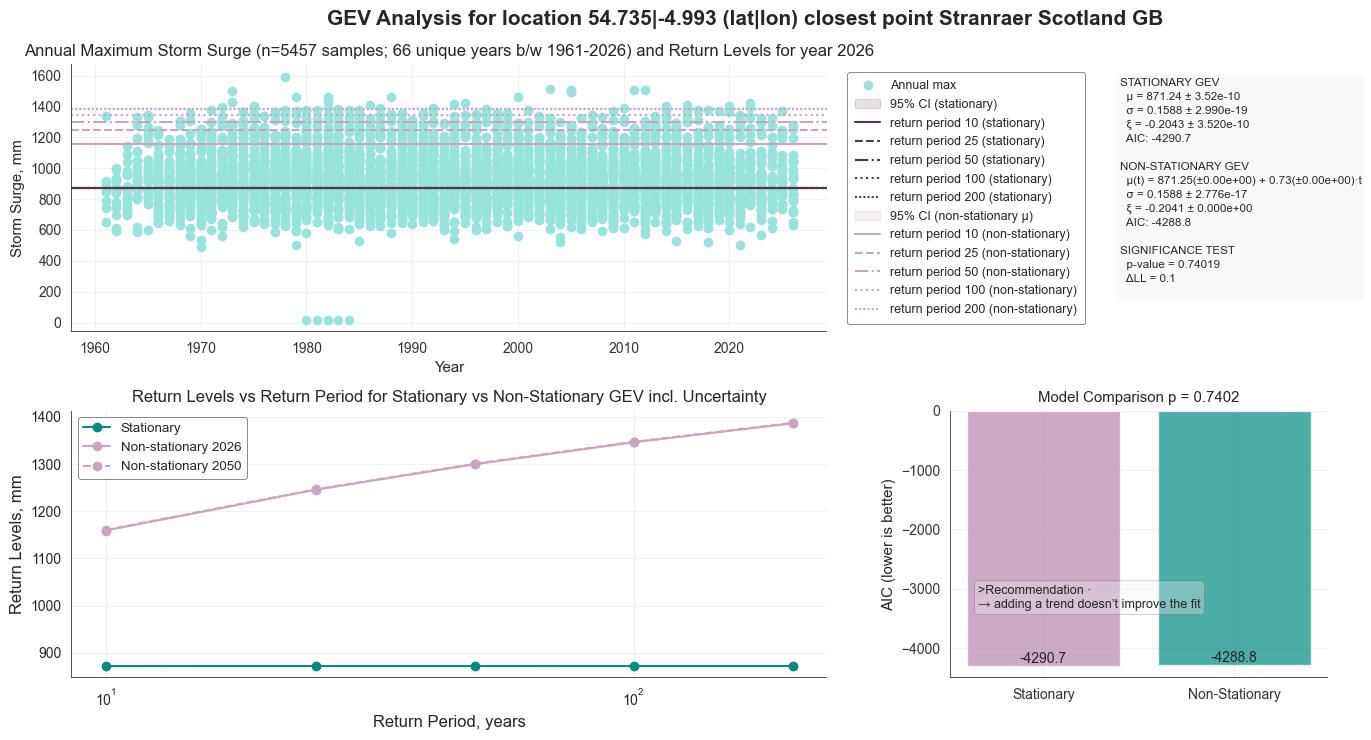

In [9]:
print(f'Process siteID {loc_id}')

fig = dbplt.plot_pooled_analysis_v2(
    result=results[loc_id], site_id=loc_id, return_periods=return_periods,
    leg_comparison_x=0.075, leg_comparison_y=0.35, box_parameters_x=0.45,  box_parameters_y= 0.95,
    linestyle_trends = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 10))], fontsize=12, figsize=(15, 7.5),
    display_results=True)

In [ ]:
dic_fig = dict(map(lambda loc_ex: (loc_ex, gev.plot_pooled_analysis_v2(
                    result=results_all[loc_ex], site_id=loc_ex, 
                    leg_comparison_x=0.075, leg_comparison_y=0.35, 
                    box_parameters_x=0.45,  box_parameters_y= 0.95,
                    linestyle_trends = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 10))],
                    fontsize=12, figsize=(15, 7.5), display_results=True
                    )), list(results_all.keys())))

## Store Result(s)

In [ ]:
today_ = str(datetime.today().date().isoformat())   
path_child_folder = Path(path_export) / f"{today_}"

ut.save_pooled_results(results=results_all, data=None, base_dir=path_child_folder)

In [ ]:
fig_dir = Path(path_child_folder) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

for loc_id, result in results_all.items():   
    fig = plot_pooled_analysis_v2(
        result=result, site_id=loc_id,
        leg_comparison_x=0.075, leg_comparison_y=0.35, 
        box_parameters_x=0.45,  box_parameters_y= 0.95,
        linestyle_trends = ['-', '--', '-.', ':', (0, (1, 1)), (0, (5, 10))],
        fontsize=12, figsize=(15, 7.5),
        )
    
    lat = str(result['LatLon'][0].round(3))
    lon = str(result['LatLon'][1].round(3))
    country = result['location_info'].split(' ')[-1].strip()

    fig.savefig(
        fig_dir / f"location_{loc_id}_{country}_{lat}_{lon}_pooledGEVanalysis.png", 
        dpi=150, bbox_inches="tight"
        )
    plt.close(fig)

# Annnual Stationary GEV Analysis

In [83]:
from typing import Optional
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
from pandas import concat
from numpy import ndarray, isfinite, all, sqrt, diag
import os

In [ ]:
def fit_stationary_gev_incl_uncertainty(
    data: ndarray,
    year: Optional[int] = None,
    print_msg: bool = False,
    uncertainty: Optional[str] = None,
    B: int = 500,
    seed: Optional[int] = None,
) -> tuple[Optional[dict], list[str]]:
    """
    Fit stationary GEV using MLE.
    Optionally estimate parameter uncertainty via parametric bootstrap or fisher.
    """
    if uncertainty is None:
        uncertainty = "fisher"
        
    ls_notes = []
    n = len(data)

    if n < 10:
        message = (
            f"Warning: Only {n} observations"
            + (f" in {year}" if year else "")
            + ". Need at least 10 for reliable GEV fit."
        )
        if print_msg:
            print(message)
        ls_notes.append(message)
        return None, ls_notes

    try:
        # ---- MLE FIT ----
        result, ls_notes = gev.mle_fitting(data, n, ls_notes)

        # ---- OPTIONAL Fisher Information ---- 
        if uncertainty == "fisher" :
            ls_notes.append('Compute Fisher Information...')
            cov = gev._compute_fisher_info(data, -result['shape'], result['location'], result['scale'])
            
            if cov is not None and all(isfinite(cov)):
                std_errors = sqrt(diag(cov))

                result.update({
                    "shape_std": std_errors[0],
                    "location_std": std_errors[1],
                    "scale_std": std_errors[2],
                })
            else:
                message = 'Failed to compute information, falling back to bootstrap (B=150)...'
                if print_msg:
                    print(message)
                ls_notes.append(message)
        
                uncertainty = "bootstrap"
                B = 150
                ls_notes.append('Compute Bootstrapping...')
                bootstrap_results = gev.stationary_gev_bootstrapping(data, B=B, seed=seed)
                
                result.update({
                    "shape_std": bootstrap_results['shape_std'],
                    "location_std": bootstrap_results['mu_std']*1000, # conversion to millimeter
                    "scale_std": bootstrap_results['scale_std'],
                    "location_samples": bootstrap_results['mu_samples'],
                    "n_obs": bootstrap_results['n_obs']
                })
                
        # ---- OPTIONAL BOOTSTRAP (more accurate) ----
        if uncertainty == "bootstrap":
            ls_notes.append('Compute Bootstrapping...')
            bootstrap_results = gev.stationary_gev_bootstrapping(data, B=B, seed=seed)
            
            result.update({
                "shape_std": bootstrap_results['shape_std'],
                "location_std": bootstrap_results['mu_std']*1000, # conversion to millimeter
                "scale_std": bootstrap_results['scale_std'],
                "location_samples": bootstrap_results['mu_samples'],
                "n_obs": bootstrap_results['n_obs']
            })
        result.update({'uncertainty': uncertainty})
        
        return result, ls_notes

    except Exception as e:
        message = f"Failed to conduct GEV fitting due to error: {e}"
        if print_msg:
            print(message)
        ls_notes.append(message)
        
        return None, ls_notes


In [88]:
def fit_all_years_stationary(df_prepared, uncertainty='fisher', seed=None):
    results_per_year = {}
    annual_max_per_year = df_prepared.groupby('sim_year')['storm_surge'].apply(list)

    for year, data in annual_max_per_year.items():
        stationary, stat_notes = fit_stationary_gev_incl_uncertainty(
            data=data,
            year=year,
            uncertainty=uncertainty,
            B=150,
            print_msg=True
        )
        results_per_year[year] = {
            "stationary": stationary,
            "notes": stat_notes
        }

    return results_per_year

In [90]:
results_annual_stat_all = dict()
def fit_location_wrapper(loc_id, df):
    return loc_id, fit_all_years_stationary(df)

results_annual_stat_mp = Parallel(n_jobs=-1, backend='loky')(
    delayed(fit_location_wrapper)(loc_id, df) for loc_id, df in dic_data_per_location.items()
)

results_annual_stat_all = dict(results_annual_stat_mp)
results_annual_stat = {
    site_id: DataFrame(
        [
            {'year': yr, **year_data['stationary']}
            for yr, year_data in site_data.items()
            if year_data.get('stationary')
        ]
    ).set_index('year')
    for site_id, site_data in results_annual_stat_all.items()
}

1961.0 8
1962.0 16
1961.0 6
1962.0 12
1961.0 12
1961.0 8
1962.0 16
1961.0 4
1962.0 8
1963.0 12
1961.0 8
1962.0 16
1961.0 8
1962.0 16
1961.0 8
1962.0 16
Compute Fisher Information
Compute Fisher Information
Compute Fisher Information
Compute Fisher Information
None
Failed to compute information, falling back to bootstrap (B=150)...
[[-1.58945674e-07  1.58945719e-07  2.29586952e-16]
 [ 1.58945719e-07 -1.58945765e-07  2.29587017e-16]
 [ 2.29586952e-16  2.29587017e-16 -3.31623800e-25]]
1963.0 24
[[ 2.06960444e-10 -2.06960573e-10  3.75448223e-19]
 [-2.06960573e-10  2.06960700e-10  3.75448456e-19]
 [ 3.75448223e-19  3.75448456e-19  6.81102948e-28]]
1963.0 24
None
Failed to compute information, falling back to bootstrap (B=150)...
Compute Fisher Information
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]
Failed to compute information, falling back to bootstrap (B=150)...


/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_65371/3226156856.py:43: RuntimeWarning: invalid value encountered in sqrt
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_65371/3226156856.py:43: RuntimeWarning: invalid value encountered in sqrt
/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_65371/3226156856.py:43: RuntimeWarning: invalid value encountered in sqrt


Compute Fisher Information
Compute Fisher Information
Compute Fisher Information
[[-7.40147150e-17  7.40148682e-17  8.82274056e-26]
 [ 7.40148682e-17 -7.40150218e-17  8.82275884e-26]
 [ 8.82274056e-26  8.82275884e-26 -1.05169291e-34]]
1963.0 24
[[ 5.97651074e-105 -5.97734268e-105  3.96728265e-112]
 [-5.97734268e-105  5.97817315e-105  3.96783437e-112]
 [ 3.96728265e-112  3.96783437e-112  2.63353189e-119]]
1964.0 15
[[-7.22799142e-20  7.22801448e-20  3.27112405e-29]
 [ 7.22801448e-20 -7.22803755e-20  3.27113448e-29]
 [ 3.27112405e-29  3.27113448e-29 -1.48039087e-38]]
1963.0 24
Compute Fisher Information
Compute Fisher Information
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]
Failed to compute information, falling back to bootstrap (B=150)...
[[ 2.36847189e-15 -2.36847579e-15  1.10920844e-24]
 [-2.36847579e-15  2.36847968e-15  1.10921026e-24]
 [ 1.10920844e-24  1.10921026e-24  5.19467160e-34]]
1964.0 31


/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)


Compute Fisher Information
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]
Failed to compute information, falling back to bootstrap (B=150)...
Compute Fisher Information
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]
Failed to compute information, falling back to bootstrap (B=150)...
Compute Fisher Information
Compute Fisher Information
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]
Failed to compute information, falling back to bootstrap (B=150)...
[[ 6.19542271e-20 -6.19544099e-20  4.12496782e-29]
 [-6.19544099e-20  6.19545926e-20  4.12497999e-29]
 [ 4.12496782e-29  4.12497999e-29  2.74644045e-38]]
1965.0 38
Compute Fisher Information
[[ 2.49126279e-23 -2.49127338e-23  5.21711301e-32]
 [-2.49127338e-23  2.49128395e-23  5.21713516e-32]
 [ 5.21711301e-32  5.21713516e-32  1.09254906e-40]]
1966.0 50
Compute Fisher Information
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]
Failed to compute information, falling back to bootstrap (B=150)...


...

2004.0 115
Compute Fisher Information
[[ 1.54885558e-20 -1.54886025e-20  1.78810507e-29]
 [-1.54886025e-20  1.54886491e-20  1.78811046e-29]
 [ 1.78810507e-29  1.78811046e-29  2.06431108e-38]]
2005.0 114
Compute Fisher Information
[[ 2.16078402e-263 -2.16309994e-263  8.50603341e-270]
 [-2.16309994e-263  2.16541493e-263  8.51514344e-270]
 [ 8.50603341e-270  8.51514344e-270  3.34844222e-276]]
2006.0 114
Compute Fisher Information
[[ 1.05878635e-24 -1.05879119e-24  1.86761049e-33]
 [-1.05879119e-24  1.05879602e-24  1.86761902e-33]
 [ 1.86761049e-33  1.86761902e-33  3.29430859e-42]]
2007.0 114
Compute Fisher Information
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]
Failed to compute information, falling back to bootstrap (B=150)...
2019.0 32
1988.0 119
Compute Fisher Information
Compute Fisher Information
[[ 1.24275117e-28 -1.24275934e-28  1.44411341e-37]
 [-1.24275934e-28  1.24276750e-28  1.44412290e-37]
 [ 1.44411341e-37  1.44412290e-37  1.67810227e-46]]
1989.0 120
[[-9.53674073e-07  9.53

/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/.venv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:3393: RuntimeWarning: overflow encountered in exp
  pex2 = np.exp(logpex2)


2024.0 48
Compute Fisher Information
[[ 2.81733300e-33 -2.81736038e-33  8.51285440e-42]
 [-2.81736038e-33  2.81738773e-33  8.51293708e-42]
 [ 8.51285440e-42  8.51293708e-42  2.57224438e-50]]
2025.0 38
Compute Fisher Information
[[ 1.22465384e-101 -1.22480027e-101  4.66524434e-109]
 [-1.22480027e-101  1.22494652e-101  4.66580180e-109]
 [ 4.66524434e-109  4.66580180e-109  1.77719647e-116]]
2026.0 28
Compute Fisher Information
[[ 6.61740938e-25 -6.61744490e-25  3.09798060e-34]
 [-6.61744490e-25  6.61748042e-25  3.09799723e-34]
 [ 3.09798060e-34  3.09799723e-34  1.45033854e-43]]
1974.0 75
Compute Fisher Information
[[ 1.21265840e-12 -1.21265960e-12  5.15739384e-22]
 [-1.21265960e-12  1.21266080e-12  5.15739896e-22]
 [ 5.15739384e-22  5.15739896e-22  2.19342160e-31]]
1975.0 78
Compute Fisher Information
[[ 2.27373417e-13 -2.27373676e-13  9.06963497e-23]
 [-2.27373676e-13  2.27373934e-13  9.06964527e-23]
 [ 9.06963497e-23  9.06964527e-23  3.61776146e-32]]
1976.0 78
Compute Fisher Information

/var/folders/lx/z70mzvpx4ls9np3hfbhll4wr0000gn/T/ipykernel_65371/3226156856.py:43: RuntimeWarning: invalid value encountered in sqrt


Compute Fisher Information
[[ 8.88176970e-16 -8.88178420e-16  5.22200661e-25]
 [-8.88178420e-16  8.88179869e-16  5.22201514e-25]
 [ 5.22200661e-25  5.22201514e-25  3.07026122e-34]]
1994.0 80
Compute Fisher Information
[[ 2.89119827e-19 -2.89120580e-19  2.99549083e-28]
 [-2.89120580e-19  2.89121331e-19  2.99549862e-28]
 [ 2.99549083e-28  2.99549862e-28  3.10354548e-37]]
1995.0 80
Compute Fisher Information
[[ 1.92506681e-23 -1.92507488e-23  2.94474776e-32]
 [-1.92507488e-23  1.92508295e-23  2.94476010e-32]
 [ 2.94474776e-32  2.94476010e-32  4.50453944e-41]]
1996.0 80
Compute Fisher Information
[[ 4.81266615e-24 -4.81268721e-24  1.23350611e-32]
 [-4.81268721e-24  4.81270823e-24  1.23351150e-32]
 [ 1.23350611e-32  1.23351150e-32  3.16152683e-41]]
1997.0 72
Compute Fisher Information
[[ 1.51582272e-13 -1.51582450e-13  6.82526840e-23]
 [-1.51582450e-13  1.51582628e-13  6.82527641e-23]
 [ 6.82526840e-23  6.82527641e-23  3.07320164e-32]]
1998.0 72
Compute Fisher Information
[[ 2.84216671e-15 

In [65]:
results_annual_stat_all = dict()
def fit_location_wrapper(loc_id, df):
    return loc_id, fit_all_years_stationary(df)

results_annual_stat_mp = Parallel(n_jobs=-1, backend='loky')(
    delayed(fit_location_wrapper)(loc_id, df) for loc_id, df in dic_data_per_location.items()
)

results_annual_stat_all = dict(results_annual_stat_mp)
results_annual_stat = {
    site_id: DataFrame(
        [
            {'year': yr, **year_data['stationary']}
            for yr, year_data in site_data.items()
            if year_data.get('stationary')
        ]
    ).set_index('year')
    for site_id, site_data in results_annual_stat_all.items()
}

1961.0 8
1962.0 16
123
1961.0 6
1962.0 12
123
1961.0 12
123
1961.0 8
1962.0 16
123
1961.0 4
1962.0 8
1963.0 12
123
1961.0 8
1962.0 16
123
1961.0 8
1962.0 16
123
234 True
Compute Fisher Information234 True

Compute Fisher Information
1961.0 8
1962.0 16
123
234 True
Compute Fisher Information
[[-1.58945674e-07  1.58945719e-07  2.29586952e-16]
 [ 1.58945719e-07 -1.58945765e-07  2.29587017e-16]
 [ 2.29586952e-16  2.29587017e-16 -3.31623800e-25]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1963.0 24
123
234 True
Compute Fisher Information
None
Failed to compute information, falling back to bootstrap (B=150)...
Failed to conduct GEV fitting due to error: name 'stationary_gev_bootstrapping' is not defined
1963.0 18
123
[[ 2.06960444e-10 -2.06960573e-10  3.75448223e-19]
 [-2.06960573e-10  2.06960700e-10  3.75448456e-19]
 [ 3.75448223e-19  3.75448456e-19  6.81102948e-28]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1963.0 24
123
234 

/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)


234 True
Compute Fisher Information
234 True
Compute Fisher Information
234 True
Compute Fisher Information
234 True
Compute Fisher Information
[[-7.40147150e-17  7.40148682e-17  8.82274056e-26]
 [ 7.40148682e-17 -7.40150218e-17  8.82275884e-26]
 [ 8.82274056e-26  8.82275884e-26 -1.05169291e-34]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1963.0 24
123
[[-7.22799142e-20  7.22801448e-20  3.27112405e-29]
 [ 7.22801448e-20 -7.22803755e-20  3.27113448e-29]
 [ 3.27112405e-29  3.27113448e-29 -1.48039087e-38]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1963.0 24
123
[[-7.45057708e-09  7.45058059e-09  3.02858944e-18]
 [ 7.45058059e-09 -7.45058412e-09  3.02859087e-18]
 [ 3.02858944e-18  3.02859087e-18 -1.23109309e-27]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1963.0 36
123
[[ 5.97651074e-105 -5.97734268e-105  3.96728265e-112]
 [-5.97734268e-105  5.97817315e-105  3.96783437e-112]
 [ 3.96728265e-112 

/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)
/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)


234 True
Compute Fisher Information
234 True
Compute Fisher Information
[[ 5.01865368e-36 -5.01870997e-36  2.04710504e-44]
 [-5.01870997e-36  5.01876618e-36  2.04712798e-44]
 [ 2.04710504e-44  2.04712798e-44  8.35012595e-53]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1966.0 37
123
234 True
Compute Fisher Information
234 True
Compute Fisher Information
234 True
Compute Fisher Information
[[ 2.49126279e-23 -2.49127338e-23  5.21711301e-32]
 [-2.49127338e-23  2.49128395e-23  5.21713516e-32]
 [ 5.21711301e-32  5.21713516e-32  1.09254906e-40]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1966.0 50
123
[[ 5.42099422e-20 -5.42101087e-20  3.25963399e-29]
 [-5.42101087e-20  5.42102750e-20  3.25964399e-29]
 [ 3.25963399e-29  3.25964399e-29  1.96001200e-38]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1966.0 48
123
[[ 1.65094906e-41 -1.65097522e-41  1.29022934e-49]
 [-1.65097522e-41  1.65100134e-41  1.290

...

/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/script/func_gev.py:1197: RuntimeWarning: invalid value encountered in scalar subtract
  hessian[i, j] = (fpp - fpm - fmp + fmm) / (4 * eps**2)


True
Compute Fisher Information
[[nan nan nan]
 [nan nan nan]
 [nan nan nan]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1965.0 28
123
234 True
Compute Fisher Information
[[ 3.17891361e-07 -3.17891439e-07  2.74456517e-16]
 [-3.17891439e-07  3.17891516e-07  2.74456584e-16]
 [ 2.74456517e-16  2.74456584e-16  2.36956360e-25]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
2023.0 24
123
[[-4.88281227e-04  4.88281249e-04  8.62228971e-13]
 [ 4.88281249e-04 -4.88281275e-04  8.62229013e-13]
 [ 8.62228971e-13  8.62229013e-13 -1.52256273e-21]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
2013.0 69
123
234 True
Compute Fisher Information
[[ 2.46516893e-32 -2.46519034e-32  6.85354597e-41]
 [-2.46519034e-32  2.46521171e-32  6.85360544e-41]
 [ 6.85354597e-41  6.85360544e-41  1.90539041e-49]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1971.0 102
123
234 True
Compute Fisher Informa

/Users/silviazieger/Coding/Python/UniCat_SeaLevelExtremes/.venv/lib/python3.12/site-packages/scipy/stats/_continuous_distns.py:3393: RuntimeWarning: overflow encountered in exp
  pex2 = np.exp(logpex2)


234 True
Compute Fisher Information
[[ 7.08054317e-37 -7.08062483e-37  3.08530117e-45]
 [-7.08062483e-37  7.08070636e-37  3.08533672e-45]
 [ 3.08530117e-45  3.08533672e-45  1.34440015e-53]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1988.0 99
123
234 True
Compute Fisher Information
234 True
Compute Fisher Information
[[ 3.15541996e-30 -3.15544363e-30  9.74459177e-39]
 [-3.15544363e-30  3.15546726e-30  9.74466481e-39]
 [ 9.74459177e-39  9.74466481e-39  3.00933219e-47]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1984.0 79
123
[[ 3.24363986e-34 -3.24367150e-34  1.11749669e-42]
 [-3.24367150e-34  3.24370308e-34  1.11750758e-42]
 [ 1.11749669e-42  1.11750758e-42  3.84999231e-51]]
Failed to conduct GEV fitting due to error: name 'isfinite' is not defined
1991.0 120
123
234 True
Compute Fisher Information
[[ 1.04456171e-34 -1.04457218e-34  3.97271792e-43]
 [-1.04457218e-34  1.04458263e-34  3.97275771e-43]
 [ 3.97271792e-43  3.972

KeyError: "None of ['year'] are in the columns"

In [13]:
def store_annual_stat_results(results_annual_stat, path_child_folder):
    os.makedirs(path_child_folder, exist_ok=True)

    # Combine dict of DataFrames into one
    combined = concat(
        results_annual_stat,
        names=["site_id"]
    ).reset_index(level=0)

    file_name = os.path.join(path_child_folder, "stationary_per_year.parquet")
    combined.to_parquet(file_name, index=False)

    print(f"Output stored in {file_name}")

In [14]:
try:
    dir_export = path_child_folder
except:
    today_ = str(datetime.today().date().isoformat())   
    dir_export = Path(path_export) / f"{today_}"
    
store_annual_stat_results(results_annual_stat, dir_export)

Output stored in ../output/gev_analysis/2026-02-24/stationary_per_year.parquet


# Regression Analysis for Location Parameter μ

In [110]:
from numpy import percentile, array, mean, random
from sklearn.linear_model import LinearRegression

In [94]:
axes_color: str = '#333333'
markers_color: str = "#99E3DDFF"
colors_reg: list = ['#333333FF', '#7F6C7BFF']  

fs = 12

In [ ]:
n_samples = 5000  # Monte Carlo draws
x_years = array(x_ans)

# Prepare storage
mu1_samples = []
mu0_samples = []

for _ in range(n_samples):
    y_sample = []
    for idx, row in results_annual_stat[loc_id].iterrows():
        if row.uncertainty == "bootstrap" and row.location_samples is not None:
            y_sample.append(random.choice(row.location_samples))
        elif row.uncertainty == "fisher" and isfinite(row.location_std) and row.location_std > 0:
            y_sample.append(random.normal(row.location, row.location_std))
        else:
            y_sample.append(row.location)
    
    y_sample = array(y_sample)
    reg = LinearRegression()
    reg.fit(x_years.reshape(-1, 1), y_sample)
    mu1_samples.append(reg.coef_[0])
    mu0_samples.append(reg.intercept_)

# Compute median trend and 95% CI
mu1_mean, mu1_ci = mean(mu1_samples), percentile(mu1_samples, [2.5, 97.5])
mu0_mean, mu0_ci = mean(mu0_samples), percentile(mu0_samples, [2.5, 97.5])

print(f"Trend slope μ1: {mu1_mean:.3f} [{mu1_ci[0]:.3f}, {mu1_ci[1]:.3f}]")
print(f"Trend intercept μ0: {mu0_mean:.3f} [{mu0_ci[0]:.3f}, {mu0_ci[1]:.3f}]")

In [95]:
x_ans = results_annual_stat[loc_id].index
y_ans = results_annual_stat[loc_id].location.values

weights_ans = results_annual_stat[loc_id].n_obs.values

In [96]:
result_nonstat = results[loc_id]['nonstationary']
mu0_ns = result_nonstat['mu0_samples']*1000
mu1_ns = result_nonstat['mu1_samples']*1000

x_ns = arange(hindcast_start, hindcast_end+1)
y_ns = mu0_ns.mean() + mu1_ns.mean()*(x_ns-result_nonstat['years_mean'])/result_nonstat['years_std']


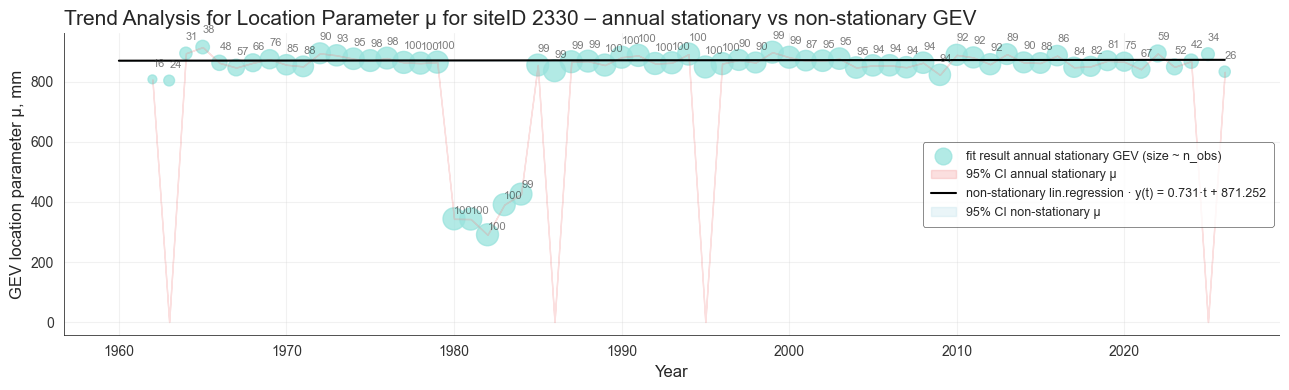

In [ ]:
fig, ax = plt.subplots(figsize=(13, 4))

# annual-stationary GEV results
ax.scatter(
        x_ans, y_ans, s=weights_ans*2.5, 
        marker='o', color=markers_color, alpha=0.75, 
        label='fit result annual stationary GEV (size ~ n_obs)'
        )
for idx, row in results_annual_stat[loc_id].iterrows():
        ax.text(idx, row.location*1.05, f"{row.n_obs}", fontsize=8, alpha=0.6)




# non-stationary GEV
plt.plot(
        x_ns, y_ns, color='k', 
        label=f'non-stationary lin.regression · y(t) = {mu1_ns.mean():.3f}·t + {mu0_ns.mean():.3f}'
        )
mu_samples_t = array([
    mu0_ns + mu1_ns * (t - result_nonstat['years_mean']) / result_nonstat['years_std'] for t in x_ns
    ])
lower_ci = percentile(mu_samples_t, 2.5, axis=1)
upper_ci = percentile(mu_samples_t, 97.5, axis=1)
ax.fill_between(x_ns, lower_ci, upper_ci, color='lightblue', alpha=0.25, label='95% CI non-stationary μ')


# ----------------------------------------------------------------------------
# layout
leg = ax.legend(loc=0, edgecolor=axes_color, borderpad=.65, fontsize=fs*0.75)
leg.get_frame().set_linewidth(.5)

for spine in ax.spines.values():
        spine.set_visible(False)

ax.axhline(y=ax.get_ylim()[0], color=axes_color, linewidth=1.2, zorder=10)
ax.axvline(x=ax.get_xlim()[0], color=axes_color, linewidth=1.2, zorder=10)

ax.tick_params(axis='x', colors=axes_color)
ax.tick_params(axis='y', colors=axes_color)

ax.grid(True, alpha=0.3, color='lightgrey')
ax.set_title(f'Trend Analysis for Location Parameter μ for siteID {loc_id} – annual stationary vs non-stationary GEV', loc='left', fontsize=fs*1.25)

ax.set_xlabel('Year', fontsize=fs)
ax.set_ylabel('GEV location parameter μ, mm', fontsize=fs)
plt.tight_layout()
